# Laboratorio Semana 4: Seq2Seq Ingles-Espanol desde cero

**Curso:** Deep Learning  
**Valor:** 4% de la nota del curso  
**Entrega:** Notebook ejecutado (.ipynb) con todas las celdas con salida visible
**Integrantes:** Vianka Castro 23201 - Ricardo Godínez 23247

---

## Contexto

Esta semana implementa un modelo Seq2Seq completo para traduccion ingles-espanol con traducciones **naturales en espanol**: el corpus tiene deliberadamente oraciones donde el espanol es mas corto (por elision del sujeto: *she sings well* -> *canta bien*), mas largo (por perifrasis verbales: *the cat sleeps* -> *el gato esta durmiendo*), o del mismo largo. Esa asimetria de largo es exactamente la razon de ser de la arquitectura Encoder-Decoder.

Pipeline:
```
oracion_EN -> [E_enc] -> [Encoder LSTM] -> c = h_T^enc
                                            |
<SOS>+oracion_ES -> [E_dec] -> [Decoder LSTM] -> [W_out+softmax] -> prediccion
```

## Reglas

- Use unicamente PyTorch. No use `nn.LSTM`, `nn.Embedding`, `nn.Linear` ni capas de alto nivel.
- El backward debe ser **manual**. No use `loss.backward()`.
- No modifique los pesos iniciales ni el corpus.
- La celda final calcula su nota automatica sobre los **60 puntos** de codigo.

In [2]:
import torch
import torch.nn.functional as F
import hashlib, numpy as np, random, time
from collections import Counter
import matplotlib.pyplot as plt

def _hash_tensor(t, decimals=5):
    arr = np.round(t.detach().numpy().astype(np.float64), decimals)
    return hashlib.sha256(arr.tobytes()).hexdigest()

_resultados = {}
print(f'PyTorch: {torch.__version__}')

PyTorch: 2.13.0+cpu


---
## Bloque 0: Corpus, vocabularios y pesos iniciales (dado, no modificar)

In [3]:
CORPUS_COMPLETO = [
    ("i love you", "te amo"),
    ("i drink water", "bebo agua"),
    ("i read the news", "leo las noticias"),
    ("i write a book", "escribo un libro"),
    ("i hear music", "escucho musica"),
    ("i call my mother", "llamo a mi madre"),
    ("i take a photo", "tomo una foto"),
    ("i finish my work", "termino mi trabajo"),
    ("i open the book", "abro el libro"),
    ("i run every morning", "corro cada manana"),
    ("i learn spanish", "aprendo espanol"),
    ("i like coffee", "me gusta el cafe"),
    ("i work every day", "trabajo todos los dias"),
    ("i buy fresh bread", "compro pan fresco"),
    ("she reads books", "lee libros"),
    ("she sings well", "canta bien"),
    ("she cooks dinner", "cocina la cena"),
    ("she opens the door", "abre la puerta"),
    ("she sleeps early", "duerme temprano"),
    ("she buys flowers", "compra flores"),
    ("she draws pictures", "dibuja imagenes"),
    ("she visits her friend", "visita a su amiga"),
    ("she teaches math", "ensena matematica"),
    ("she paints a picture", "pinta un cuadro"),
    ("she writes a poem", "escribe un poema"),
    ("she enjoys the music", "disfruta la musica"),
    ("she prepares the meal", "prepara la comida"),
    ("he runs fast", "corre rapido"),
    ("he writes a letter", "escribe una carta"),
    ("he closes the window", "cierra la ventana"),
    ("he eats an apple", "come una manzana"),
    ("he drives a car", "conduce un carro"),
    ("he fixes the bike", "arregla la bicicleta"),
    ("he plays the guitar", "toca la guitarra"),
    ("he studies history", "estudia historia"),
    ("he answers the phone", "contesta el telefono"),
    ("he repairs the chair", "repara la silla"),
    ("he teaches the class", "ensena la clase"),
    ("we eat bread", "comemos pan"),
    ("we walk together", "caminamos juntos"),
    ("we leave early", "salimos temprano"),
    ("we cook together", "cocinamos juntos"),
    ("we swim in the sea", "nadamos en el mar"),
    ("we watch the stars", "miramos las estrellas"),
    ("we visit the museum", "visitamos el museo"),
    ("we celebrate together", "celebramos juntos"),
    ("we enjoy the summer", "disfrutamos el verano"),
    ("they play soccer", "juegan futbol"),
    ("they arrive late", "llegan tarde"),
    ("they build a house", "construyen una casa"),
    ("they clean the room", "limpian el cuarto"),
    ("they watch the movie", "ven la pelicula"),
    ("they travel by train", "viajan en tren"),
    ("they eat together", "comen juntos"),
    ("they sing a song", "cantan una cancion"),
    ("they dance all night", "bailan toda la noche"),
    ("they plant the seeds", "plantan las semillas"),
    ("they clean the street", "limpian la calle"),
    ("the cat sleeps", "el gato esta durmiendo"),
    ("the dog barks", "el perro esta ladrando"),
    ("the bird flies", "el pajaro esta volando"),
    ("the sun shines", "el sol esta brillando"),
    ("the fish swims", "el pez esta nadando"),
    ("the baby laughs", "el bebe esta riendo"),
    ("the teacher explains", "el profesor esta explicando"),
    ("the rain falls", "la lluvia esta cayendo"),
    ("the moon rises", "la luna esta subiendo"),
    ("the wind blows", "el viento esta soplando"),
    ("the fire burns", "el fuego esta ardiendo"),
    ("the clock ticks", "el reloj esta sonando"),
    ("we study english", "estudiamos ingles"),
    ("we paint the wall", "pintamos la pared"),
    ("we drink hot tea", "bebemos te caliente"),
    ("we meet every week", "nos reunimos cada semana"),
    ("the cat drinks milk", "el gato bebe leche"),
    ("the child plays", "el nino juega"),
    ("he reads the newspaper", "lee el periodico"),
    ("she closes her eyes", "cierra los ojos"),
]

# Split 75/25 reproducible
random.seed(42)
indices = list(range(len(CORPUS_COMPLETO)))
random.shuffle(indices)
n_train = int(len(CORPUS_COMPLETO) * 0.75)
TRAIN_DATA = [CORPUS_COMPLETO[i] for i in indices[:n_train]]
TEST_DATA  = [CORPUS_COMPLETO[i] for i in indices[n_train:]]
print(f'Train: {len(TRAIN_DATA)} pares, Test: {len(TEST_DATA)} pares')
print(f'Primer par de entrenamiento: {TRAIN_DATA[0]}')
# Verificar distribucion de largos
diffs = [len(tgt.split())-len(src.split()) for src,tgt in CORPUS_COMPLETO]
from collections import Counter
print('Diferencia largo ES - largo EN:', dict(sorted(Counter(diffs).items())))


Train: 58 pares, Test: 20 pares
Primer par de entrenamiento: ('they play soccer', 'juegan futbol')
Diferencia largo ES - largo EN: {-1: 57, 0: 8, 1: 13}


In [4]:
SOS, EOS, PAD, UNK = '<SOS>', '<EOS>', '<PAD>', '<UNK>'
SPECIAL = [PAD, UNK, SOS, EOS]

def build_vocab(sentences):
    words = set()
    for s in sentences: words.update(s.lower().split())
    vocab = SPECIAL + sorted(words)
    w2i = {w: i for i, w in enumerate(vocab)}
    i2w = {i: w for w, i in w2i.items()}
    return vocab, w2i, i2w

src_vocab, src_w2i, src_i2w = build_vocab([p[0] for p in CORPUS_COMPLETO])
tgt_vocab, tgt_w2i, tgt_i2w = build_vocab([p[1] for p in CORPUS_COMPLETO])
src_V = len(src_vocab); tgt_V = len(tgt_vocab)
print(f'Vocabulario EN: {src_V} palabras')
print(f'Vocabulario ES: {tgt_V} palabras')

def tokenize_src(sentence):
    return [src_w2i.get(w.lower(), src_w2i[UNK]) for w in sentence.split()]

def tokenize_tgt(sentence):
    return ([tgt_w2i[SOS]] +
            [tgt_w2i.get(w.lower(), tgt_w2i[UNK]) for w in sentence.split()] +
            [tgt_w2i[EOS]])

Vocabulario EN: 158 palabras
Vocabulario ES: 163 palabras


In [5]:
d_emb = 16; d_hid = 32
torch.manual_seed(42)
E_enc = torch.randn(d_emb, src_V) * 0.1
E_dec = torch.randn(d_emb, tgt_V) * 0.1
Wf_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bf_enc=torch.zeros(d_hid)
Wi_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bi_enc=torch.zeros(d_hid)
Wc_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bc_enc=torch.zeros(d_hid)
Wo_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bo_enc=torch.zeros(d_hid)
Wf_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bf_dec=torch.zeros(d_hid)
Wi_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bi_dec=torch.zeros(d_hid)
Wc_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bc_dec=torch.zeros(d_hid)
Wo_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bo_dec=torch.zeros(d_hid)
W_out = torch.randn(tgt_V, d_hid) * 0.1; b_out = torch.zeros(tgt_V)
alpha = 0.01
print(f'E_enc: {E_enc.shape}, Wf_enc: {Wf_enc.shape}, W_out: {W_out.shape}')

E_enc: torch.Size([16, 158]), Wf_enc: torch.Size([32, 48]), W_out: torch.Size([163, 32])


---
## Bloque 1: Lookup de embeddings

Implemente `get_embedding` que selecciona la columna `idx` de la matriz `E`:

$$\mathbf{e} = E[:, \text{idx}]$$

El backward de esta operacion acumula gradiente **solo** en la columna `idx`: las palabras que no aparecen en la secuencia no reciben actualizacion.

Implemente tambien `get_embedding_batch` para una lista de indices.

In [6]:
def get_embedding(E, idx):
    """
    Selecciona la columna idx de E. Retorna tensor (d_emb,).
    """
    return E[:,idx]
    

def get_embedding_batch(E, indices):
    """Retorna lista de embeddings para una lista de indices."""
    # SU CODIGO AQUI
    return [get_embedding(E, idx) for idx in indices]
    

emb_test = get_embedding(E_enc, 0)
print(f'Embedding token 0: {emb_test.shape if emb_test is not None else None}')

Embedding token 0: torch.Size([16])


---
## Bloque 2: Celda LSTM y forward del encoder

Implemente `lstm_cell` con las cinco ecuaciones del LSTM.  
Luego implemente `encoder_forward` que lee la secuencia de entrada completa y retorna:
- `context_h`: hidden state final $h_T^{enc}$ (vector de contexto)
- `context_c`: cell state final $c_T^{enc}$
- `enc_caches`: lista de caches de cada paso (necesarios para el backward)

Guarde el indice del embedding en cada cache con la clave `'emb_idx'`.

**Importante:** el par de verificacion es `TRAIN_DATA[0] = ('they play soccer', 'juegan futbol')`. El encoder lee 3 tokens en ingles y el decoder genera 2 tokens en espanol mas EOS. Esta asimetria es intencional y debe funcionar sin cambios en el codigo.

In [7]:
def lstm_cell(h, c, x, Wf, bf, Wi, bi, Wc, bc, Wo, bo):
    """
    Un paso de tiempo LSTM.
    Retorna (h_new, c_new, cache).
    El cache debe contener: concat, h_prev, c_prev, f, i, ct, c_t, o, h_t
    """
    # SU CODIGO AQUI
    # unir estado anterior con el embedding de entrada actual 
    concat = torch.cat((h,x))
    #compuerta de olvido 
    f = torch.sigmoid(Wf @ concat + bf)
    #compuerta de entrada
    i = torch.sigmoid(Wi @ concat + bi)
    #info candidata para guardar
    ct = torch.tanh(Wc @ concat + bc)
    # memoria interna nueva 
    c_t = f * c + i * ct
    #compuerta de salida
    o = torch.sigmoid(Wo @ concat + bo)
    #estado oculto nuevo
    h_t = o * torch.tanh(c_t)
    #cuargar todo en cache para backward 
    cache = {
        'concat': concat,
        'h_prev': h,
        'c_prev': c,
        'f': f,
        'i': i,
        'ct': ct,
        'c_t': c_t,
        'o': o,
        'h_t': h_t
    }

    return h_t, c_t, cache


def encoder_forward(src_indices, E_enc, Wf_enc, bf_enc, Wi_enc, bi_enc,
                    Wc_enc, bc_enc, Wo_enc, bo_enc):
    """
    Forward del encoder. Retorna (context_h, context_c, enc_caches).
    """
    h = torch.zeros(d_hid); c = torch.zeros(d_hid); caches = []
    # SU CODIGO AQUI
    #Procesamiento de cada palabra de la oracion ingles
    for idx in src_indices:
        # convetir el indice a embedding
        x = get_embedding(E_enc, idx)
        # ejecutar un paso de la LSTM
        h, c, cache = lstm_cell(
            h,c,x,
            Wf_enc, bf_enc,
            Wi_enc, bi_enc,
            Wc_enc, bc_enc,
            Wo_enc, bo_enc
        )
        #guardar palabra produjo 
        cache['emb_idx'] = idx
        caches.append(cache)
    return h, c, caches

# Verificar con TRAIN_DATA[0]: 'they play soccer' -> 'juegan futbol'
src_test = tokenize_src(TRAIN_DATA[0][0])
context_h, context_c, enc_caches = encoder_forward(
    src_test, E_enc, Wf_enc, bf_enc, Wi_enc, bi_enc, Wc_enc, bc_enc, Wo_enc, bo_enc)
print(f'Entrada EN: {TRAIN_DATA[0][0]} -> tokens: {src_test}')
print(f'context_h forma: {context_h.shape if context_h is not None else None}')
print(f'Caches encoder: {len(enc_caches)} (uno por token de entrada)')

Entrada EN: they play soccer -> tokens: [138, 103, 122]
context_h forma: torch.Size([32])
Caches encoder: 3 (uno por token de entrada)


In [8]:
# VERIFICACION BLOQUE 2
_H = 'a1c22d089ecfb52bdae47e330603a46d492f9318dc6b2071956ef1a9c406eeec'
try:
    assert context_h is not None and context_h.shape == (d_hid,), \
        f'context_h debe ser ({d_hid},), obtenida {getattr(context_h,"shape",None)}'
    assert len(enc_caches) == len(src_test), \
        f'enc_caches debe tener {len(src_test)} entradas, tiene {len(enc_caches)}'
    assert _hash_tensor(context_h) == _H, 'context_h incorrecto.'
    _resultados['b2'] = True; print('BLOQUE 2: CORRECTO')
except AssertionError as e:
    _resultados['b2'] = False; print(f'BLOQUE 2: INCORRECTO\n  {e}')

BLOQUE 2: CORRECTO


---
## Bloque 3: Forward del decoder con teacher forcing

Implemente `decoder_forward` con teacher forcing.

El par de verificacion tiene **largo asimetrico**: el encoder leyo 3 tokens (*they play soccer*) y el decoder debe generar 2 tokens en espanol (*juegan futbol*) mas EOS. Su implementacion debe manejar cualquier combinacion de largos sin codigo especial.

- Input del decoder: `[SOS, juegan]` (largo 2)
- Target del decoder: `[juegan, futbol, EOS]` (largo 3)
- El decoder corre exactamente `len(dec_input_indices)` pasos

In [9]:
def decoder_forward(dec_input_indices, dec_target_indices, context_h, context_c,
                    E_dec, Wf_dec, bf_dec, Wi_dec, bi_dec,
                    Wc_dec, bc_dec, Wo_dec, bo_dec, W_out, b_out):
    """
    Forward decoder con teacher forcing.
    Retorna (logits_list, dec_caches)
    logits_list: lista de tensores (tgt_V,), uno por paso
    """
    h = context_h.clone(); c = context_c.clone()
    caches = []; logits_list = []
    # SU CODIGO AQUI
    # procesar cada entrada del decoder 
    for idx in dec_input_indices:
        # convertir el indice a embedding
        x = get_embedding(E_dec, idx)
        # ejecutar un paso de la LSTM
        h, c, cache = lstm_cell(
            h,c,x,
            Wf_dec, bf_dec,
            Wi_dec, bi_dec,
            Wc_dec, bc_dec,
            Wo_dec, bo_dec
        )
        #  guardar el indice del embedding usado 
        cache['emb_idx'] = idx
        caches.append(cache)
        # convertie el hidden state en puntuaciones 
        # para todas las palabras dle voc en esp 
        logits = W_out @ h + b_out
        logits_list.append(logits)
    return logits_list, caches

tgt_tokens_full = tokenize_tgt(TRAIN_DATA[0][1])
dec_input_idx  = tgt_tokens_full[:-1]   # [SOS, juegan]
dec_target_idx = tgt_tokens_full[1:]    # [juegan, futbol, EOS]
print(f'Salida ES: {TRAIN_DATA[0][1]} -> tokens: {tgt_tokens_full}')
print(f'Input decoder:  {dec_input_idx}  (largo {len(dec_input_idx)})')
print(f'Target decoder: {dec_target_idx} (largo {len(dec_target_idx)})')
print(f'Largo EN ({len(src_test)}) != Largo ES ({len(dec_target_idx)}): asimetria correcta')
logits_list, dec_caches = decoder_forward(
    dec_input_idx, dec_target_idx, context_h, context_c,
    E_dec, Wf_dec, bf_dec, Wi_dec, bi_dec, Wc_dec, bc_dec, Wo_dec, bo_dec, W_out, b_out)
print(f'Pasos del decoder: {len(logits_list)}')
print(f'Forma de cada logit: {logits_list[0].shape if logits_list else None}')

Salida ES: juegan futbol -> tokens: [2, 81, 73, 3]
Input decoder:  [2, 81, 73]  (largo 3)
Target decoder: [81, 73, 3] (largo 3)
Largo EN (3) != Largo ES (3): asimetria correcta
Pasos del decoder: 3
Forma de cada logit: torch.Size([163])


---
## Bloque 4: Perdida de entropia cruzada categorica

$$L = \frac{1}{S} \sum_{s=1}^{S} \left(-\log \hat{y}_s[w_s^*]\right)$$

Use `F.log_softmax` para estabilidad numerica. Resultado: tensor escalar.

In [10]:
def compute_loss(logits_list, target_indices):
    """
    Entropia cruzada categorica promedio sobre la secuencia.
    Retorna tensor escalar.
    """
    # SU CODIGO AQUI
    losses = []
    for logits, target_idx in zip(logits_list, target_indices):
        # convertir logits en log-prob 
        log_probs = F.log_softmax(logits, dim=0)
        # perdida de la palabra correcta 
        loss_step = -log_probs[target_idx]
        losses.append(loss_step)
    # promedio de las perdidas
    return torch.stack(losses).mean()

S = len(dec_target_idx)
loss_mean = compute_loss(logits_list, dec_target_idx)
print(f'S (largo secuencia decodificada): {S}')
print(f'loss_mean: {loss_mean.item() if loss_mean is not None else None:.4f}')

S (largo secuencia decodificada): 3
loss_mean: 5.0933


In [11]:
# VERIFICACION BLOQUE 4
try:
    assert loss_mean is not None, 'loss_mean no definido.'
    assert abs(loss_mean.item() - 5.093276) < 1e-3, \
        f'loss_mean incorrecto: {loss_mean.item():.6f}, esperado ~5.093'
    _resultados['b4'] = True; print('BLOQUE 4: CORRECTO')
except AssertionError as e:
    _resultados['b4'] = False; print(f'BLOQUE 4: INCORRECTO\n  {e}')

BLOQUE 4: CORRECTO


---
## BACKWARD PASS

---

## Bloque 5: Backward del decoder

BPTT sobre los $S$ pasos del decoder en orden inverso.

En cada paso $s$:
1. $\frac{\partial L}{\partial z_s} = \frac{1}{S}\left(\hat{y}_s - \mathbf{1}_{w_s^*}\right)$
2. Acumular en `dW_out`, `db_out`
3. Gradiente hacia $h_s^{dec}$: suma de `W_out.T @ dL_dz` y el gradiente del paso siguiente
4. BPTT de la celda LSTM
5. Acumular en pesos del decoder y en `dE_dec[:, emb_idx]`
6. Propagar `dL_dh_next` y `dL_dc_next`

Al salir del loop: `dL_dh_context = dL_dh_dec_next` inicia el backward del encoder.

In [12]:
dWf_dec=torch.zeros_like(Wf_dec); dbf_dec=torch.zeros_like(bf_dec)
dWi_dec=torch.zeros_like(Wi_dec); dbi_dec=torch.zeros_like(bi_dec)
dWc_dec=torch.zeros_like(Wc_dec); dbc_dec=torch.zeros_like(bc_dec)
dWo_dec=torch.zeros_like(Wo_dec); dbo_dec=torch.zeros_like(bo_dec)
dW_out =torch.zeros_like(W_out);  db_out =torch.zeros_like(b_out)
dE_dec =torch.zeros_like(E_dec)
dL_dh_dec_next = torch.zeros(d_hid)
dL_dc_dec_next = torch.zeros(d_hid)

for s in reversed(range(S)):
    cc = dec_caches[s]
    z  = logits_list[s]
    tgt_idx = dec_target_idx[s]
    # SU CODIGO AQUI
    # ========= gradiente de la entropia cruzada a los logits ====
    probs = F.softmax(z, dim=0)

    dL_dz = probs.clone()
    dL_dz[tgt_idx] -= 1.0  # gradiente de la entropia cruzada para la palabra correcta
    # perdida es promedio de S pasos
    dL_dz /= S

    # ====== gradiente de la capa de salida a h_t ======
    dW_out += torch.outer(dL_dz, cc['h_t'])
    db_out += dL_dz

    # gradiente que regresa desde la capa de salida hacia h 
    dh = W_out.T @ dL_dz + dL_dh_dec_next

    # ========= bACKWARD LSTM CELL =========
    tanh_c = torch.tanh(cc['c_t'])
    do = dh * tanh_c 
    dc = (
        dL_dc_dec_next + dh * cc['o'] * (1 - tanh_c ** 2)
    )

    # ======== backward de c_t = f * c_prev + i * ct ========
    df = dc * cc['c_prev']
    dc_prev = dc * cc['f']
    di = dc * cc['ct']
    dct = dc * cc['i']

    # ======== derivada de sigmoid y tanh ======
    daf = df * cc['f'] * (1 - cc['f'])
    dai = di * cc['i'] * (1 - cc['i'])
    dact = dct * (1 - cc['ct'] ** 2)
    dao = do * cc['o'] * (1 - cc['o'])

    # ====== gradiente de los pesos y bias de las compuertas =======
    dWf_dec += torch.outer(daf, cc['concat'])
    dbf_dec += daf
    dWi_dec += torch.outer(dai, cc['concat'])
    dbi_dec += dai
    dWc_dec += torch.outer(dact, cc['concat'])
    dbc_dec += dact
    dWo_dec += torch.outer(dao, cc['concat'])
    dbo_dec += dao

    # =========== gradiente respecto a la concatenacion [h_prev, x] ==========
    dconcat = (
        Wf_dec.T @ daf +
        Wi_dec.T @ dai +
        Wc_dec.T @ dact +
        Wo_dec.T @ dao

    )
    # PARTE 1 gradiente hacia h del anterior
    dL_dh_dec_next = dconcat[:d_hid]
    # PARTE 2 gradiente hacia x (embedding)
    dx = dconcat[d_hid:]
    # gradiente hacia memoria c 
    dL_dc_dec_next = dc_prev
    # ====== gradiente hacia embedding ======
    dE_dec[:, cc['emb_idx']] += dx

dL_dh_context = dL_dh_dec_next.clone()
dL_dc_context = dL_dc_dec_next.clone()
print(f'dWf_dec forma: {dWf_dec.shape}')
print(f'dL_dh_context forma: {dL_dh_context.shape}')

dWf_dec forma: torch.Size([32, 48])
dL_dh_context forma: torch.Size([32])


In [13]:
# VERIFICACION BLOQUE 5
_H = '91fcfa6f4bce42112eeec9128a60f328dcf657eb74249caafef27b17fc772547'
try:
    assert _hash_tensor(dWf_dec) == _H, 'dWf_dec incorrecto.'
    _resultados['b5'] = True; print('BLOQUE 5: CORRECTO')
except AssertionError as e:
    _resultados['b5'] = False; print(f'BLOQUE 5: INCORRECTO\n  {e}')

BLOQUE 5: CORRECTO


---
## Bloque 6: Backward del encoder

`dL_dh_context` entra al encoder como gradiente de $h_T^{enc}$.  
Aplique BPTT sobre los $T$ pasos del encoder en orden inverso,  
acumulando gradientes en los pesos del encoder y en `dE_enc[:, emb_idx]`.

In [14]:
dWf_enc=torch.zeros_like(Wf_enc); dbf_enc=torch.zeros_like(bf_enc)
dWi_enc=torch.zeros_like(Wi_enc); dbi_enc=torch.zeros_like(bi_enc)
dWc_enc=torch.zeros_like(Wc_enc); dbc_enc=torch.zeros_like(bc_enc)
dWo_enc=torch.zeros_like(Wo_enc); dbo_enc=torch.zeros_like(bo_enc)
dE_enc =torch.zeros_like(E_enc)
dL_dh_enc_next = dL_dh_context.clone()
dL_dc_enc_next = dL_dc_context.clone()

for t in reversed(range(len(enc_caches))):
        cc = enc_caches[t]

        # unica fuente de gradiente hacia h: no hay capa de salida en el encoder
        dh = dL_dh_enc_next

        # ===== backward LSTM cell, identico al Bloque 5 =====
        tanh_c = torch.tanh(cc['c_t'])
        do = dh * tanh_c
        dc = dL_dc_enc_next + dh * cc['o'] * (1 - tanh_c ** 2)

        df = dc * cc['c_prev']
        dc_prev = dc * cc['f']
        di = dc * cc['ct']
        dct = dc * cc['i']

        daf = df * cc['f'] * (1 - cc['f'])
        dai = di * cc['i'] * (1 - cc['i'])
        dact = dct * (1 - cc['ct'] ** 2)
        dao = do * cc['o'] * (1 - cc['o'])

        dWf_enc += torch.outer(daf, cc['concat']); dbf_enc += daf
        dWi_enc += torch.outer(dai, cc['concat']); dbi_enc += dai
        dWc_enc += torch.outer(dact, cc['concat']); dbc_enc += dact
        dWo_enc += torch.outer(dao, cc['concat']); dbo_enc += dao

        dconcat = (
            Wf_enc.T @ daf +
            Wi_enc.T @ dai +
            Wc_enc.T @ dact +
            Wo_enc.T @ dao
        )
        dL_dh_enc_next = dconcat[:d_hid]   # va al paso anterior
        dx = dconcat[d_hid:]               # va al embedding
        dL_dc_enc_next = dc_prev

        dE_enc[:, cc['emb_idx']] += dx
    
pass

print(f'dWf_enc forma: {dWf_enc.shape}')
print(f'dE_enc forma:  {dE_enc.shape}')

dWf_enc forma: torch.Size([32, 48])
dE_enc forma:  torch.Size([16, 158])


In [15]:
# VERIFICACION BLOQUE 6
_HASHES_B6 = {
    'dWf_enc': '3fafa04007ed020a0ccd8969f95aa4ba130aafd7aa4b60a7efbbcbc73593f2c5',
    'dE_enc':  '56bb53461e329a75e94c28b9cc4599d9461b9302793853a5d698b8905f6df7d5',
}
try:
    assert _hash_tensor(dWf_enc) == _HASHES_B6['dWf_enc'], 'dWf_enc incorrecto.'
    assert _hash_tensor(dE_enc)  == _HASHES_B6['dE_enc'],  'dE_enc incorrecto.'
    _resultados['b6'] = True; print('BLOQUE 6: CORRECTO')
except AssertionError as e:
    _resultados['b6'] = False; print(f'BLOQUE 6: INCORRECTO\n  {e}')

BLOQUE 6: CORRECTO


---
## Bloque 7: Gradientes de embeddings - version completa vs diccionario

Ya tiene `dE_enc` completa (misma forma que `E_enc`, ceros en columnas no usadas).  
Implemente la version eficiente con diccionario: guarda solo los gradientes de las columnas que aparecieron en la secuencia.  
Mida el tiempo de actualizacion con ambas versiones sobre 1000 repeticiones y compare.

In [16]:
def compute_dE_dict(enc_caches, dL_dh_context, dL_dc_context,
                    Wf_enc, Wi_enc, Wc_enc, Wo_enc):
    """
    Gradiente de embeddings del encoder usando diccionario.
    Retorna dict {idx: grad_tensor (d_emb,)}
    """
    dE_dict = {}
    dh_next = dL_dh_context.clone()
    dc_next = dL_dc_context.clone()
    for t in reversed(range(len(enc_caches))):
        cc = enc_caches[t]

        # identico al Bloque 6: unica fuente de gradiente hacia h
        dh = dh_next

        tanh_c = torch.tanh(cc['c_t'])
        do = dh * tanh_c
        dc = dc_next + dh * cc['o'] * (1 - tanh_c ** 2)

        df = dc * cc['c_prev']
        dc_prev = dc * cc['f']
        di = dc * cc['ct']
        dct = dc * cc['i']

        daf = df * cc['f'] * (1 - cc['f'])
        dai = di * cc['i'] * (1 - cc['i'])
        dact = dct * (1 - cc['ct'] ** 2)
        dao = do * cc['o'] * (1 - cc['o'])

        # aqui no acumulamos dW: esta funcion solo devuelve gradiente de embeddings
        dconcat = (
            Wf_enc.T @ daf +
            Wi_enc.T @ dai +
            Wc_enc.T @ dact +
            Wo_enc.T @ dao
        )
        dh_next = dconcat[:d_hid]
        dx = dconcat[d_hid:]
        dc_next = dc_prev

        # acumular en el diccionario, no en una matriz densa
        idx = cc['emb_idx']
        dE_dict[idx] = dE_dict.get(idx, torch.zeros(d_emb)) + dx

    return dE_dict

N_rep = 1000
t0 = time.time()
for _ in range(N_rep): _ = E_enc - alpha * dE_enc
t_full = (time.time()-t0)/N_rep*1e6

dE_dict = compute_dE_dict(enc_caches, dL_dh_context, dL_dc_context,
                           Wf_enc, Wi_enc, Wc_enc, Wo_enc)
t0 = time.time()
for _ in range(N_rep):
    E_tmp = E_enc.clone()
    for idx, grad in (dE_dict or {}).items(): E_tmp[:, idx] -= alpha * grad
t_dict = (time.time()-t0)/N_rep*1e6

print(f'Actualizacion completa:    {t_full:.2f} us')
print(f'Actualizacion diccionario: {t_dict:.2f} us')
print(f'Tokens con gradiente: {len(dE_dict) if dE_dict else 0} de {src_V}')

Actualizacion completa:    15.92 us
Actualizacion diccionario: 177.21 us
Tokens con gradiente: 3 de 158


In [17]:
# VERIFICACION BLOQUE 7
try:
    assert dE_dict is not None and len(dE_dict) > 0, 'dE_dict vacio.'
    dE_from_dict = torch.zeros_like(E_enc)
    for idx, grad in dE_dict.items(): dE_from_dict[:, idx] += grad
    assert torch.allclose(dE_enc, dE_from_dict, atol=1e-5), \
        'Version diccionario produce valores distintos a la version completa.'
    _resultados['b7'] = True; print('BLOQUE 7: CORRECTO')
    print(f'  Ambas versiones coinciden. {len(dE_dict)} de {src_V} tokens tienen gradiente.')
except AssertionError as e:
    _resultados['b7'] = False; print(f'BLOQUE 7: INCORRECTO\n  {e}')

BLOQUE 7: CORRECTO
  Ambas versiones coinciden. 3 de 158 tokens tienen gradiente.


---
## Bloque 8: Actualizacion de todos los parametros

$\theta \leftarrow \theta - \alpha \cdot \frac{\partial L}{\partial \theta}$

Actualice: `E_enc`, `E_dec`, pesos del encoder, pesos del decoder, `W_out`, `b_out`.

In [23]:
# SU CODIGO AQUI
E_enc_new = E_enc - alpha * dE_enc
E_dec_new = E_dec - alpha * dE_dec

Wf_enc_new = Wf_enc - alpha * dWf_enc; bf_enc_new = bf_enc - alpha * dbf_enc
Wi_enc_new = Wi_enc - alpha * dWi_enc; bi_enc_new = bi_enc - alpha * dbi_enc
Wc_enc_new = Wc_enc - alpha * dWc_enc; bc_enc_new = bc_enc - alpha * dbc_enc
Wo_enc_new = Wo_enc - alpha * dWo_enc; bo_enc_new = bo_enc - alpha * dbo_enc

Wf_dec_new = Wf_dec - alpha * dWf_dec; bf_dec_new = bf_dec - alpha * dbf_dec
Wi_dec_new = Wi_dec - alpha * dWi_dec; bi_dec_new = bi_dec - alpha * dbi_dec
Wc_dec_new = Wc_dec - alpha * dWc_dec; bc_dec_new = bc_dec - alpha * dbc_dec
Wo_dec_new = Wo_dec - alpha * dWo_dec; bo_dec_new = bo_dec - alpha * dbo_dec

W_out_new = W_out - alpha * dW_out
b_out_new = b_out - alpha * db_out
# ... actualizar todos los parametros
print(f'Wf_enc_new: {Wf_enc_new.shape if Wf_enc_new is not None else None}')

Wf_enc_new: torch.Size([32, 48])


In [24]:
# VERIFICACION BLOQUE 8
_HASHES_B8 = {
    'Wf_enc_new': '9484b49eb6a3827a17e2d2e1ed82d0012876da431dd28c4e3e41339953164a5f',
    'Wf_dec_new': 'c0b498ec57c491ada12eb038d82815a69922c7b6052614c5ab02293e10a355be',
    'W_out_new':  '274122975dcbbd5b8e1cd2e3f7cf577c6332fdb8b517d60641d628af0a704382',
}
try:
    for name, arr in [('Wf_enc_new',Wf_enc_new),('Wf_dec_new',Wf_dec_new),('W_out_new',W_out_new)]:
        assert arr is not None, f'{name} no definido.'
        assert _hash_tensor(arr) == _HASHES_B8[name], f'{name} incorrecto.'
    _resultados['b8'] = True; print('BLOQUE 8: CORRECTO')
except AssertionError as e:
    _resultados['b8'] = False; print(f'BLOQUE 8: INCORRECTO\n  {e}')

BLOQUE 8: CORRECTO


---
## Bloque 9: Loop de entrenamiento y convergencia

5 iteraciones sobre el corpus completo de entrenamiento.  
En cada iteracion: forward, loss, backward, actualizacion para cada par en `TRAIN_DATA`.  
La asimetria de largo entre ingles y espanol se maneja automaticamente: el encoder corre `len(src_tokens)` pasos y el decoder corre `len(tgt_tokens)-1` pasos, sin importar que sean distintos.  
Guardar la loss promedio del corpus en `losses_train`.

In [25]:
torch.manual_seed(42)
E_enc_tr=torch.randn(d_emb,src_V)*0.1; E_dec_tr=torch.randn(d_emb,tgt_V)*0.1
Wfe=torch.randn(d_hid,d_hid+d_emb)*0.1; bfe=torch.zeros(d_hid)
Wie=torch.randn(d_hid,d_hid+d_emb)*0.1; bie=torch.zeros(d_hid)
Wce=torch.randn(d_hid,d_hid+d_emb)*0.1; bce=torch.zeros(d_hid)
Woe=torch.randn(d_hid,d_hid+d_emb)*0.1; boe=torch.zeros(d_hid)
Wfd=torch.randn(d_hid,d_hid+d_emb)*0.1; bfd=torch.zeros(d_hid)
Wid=torch.randn(d_hid,d_hid+d_emb)*0.1; bid=torch.zeros(d_hid)
Wcd=torch.randn(d_hid,d_hid+d_emb)*0.1; bcd=torch.zeros(d_hid)
Wod=torch.randn(d_hid,d_hid+d_emb)*0.1; bod=torch.zeros(d_hid)
Wo2=torch.randn(tgt_V,d_hid)*0.1; bo2=torch.zeros(tgt_V)


def decoder_backward(logits_list, dec_target_idx, dec_caches, Wf_dec, Wi_dec, Wc_dec, Wo_dec, W_out):
    S = len(dec_caches)
Wce=torch.randn(d_hid,d_hid+d_emb)*0.1; bce=torch.zeros(d_hid)
Woe=torch.randn(d_hid,d_hid+d_emb)*0.1; boe=torch.zeros(d_hid)
Wfd=torch.randn(d_hid,d_hid+d_emb)*0.1; bfd=torch.zeros(d_hid)
Wid=torch.randn(d_hid,d_hid+d_emb)*0.1; bid=torch.zeros(d_hid)
Wcd=torch.randn(d_hid,d_hid+d_emb)*0.1; bcd=torch.zeros(d_hid)
Wod=torch.randn(d_hid,d_hid+d_emb)*0.1; bod=torch.zeros(d_hid)
Wo2=torch.randn(tgt_V,d_hid)*0.1; bo2=torch.zeros(tgt_V)


def decoder_backward(logits_list, dec_target_idx, dec_caches, Wf_dec, Wi_dec, Wc_dec, Wo_dec, W_out):
    S = len(dec_caches)
    dWf_dec = torch.zeros(d_hid, d_hid+d_emb); dbf_dec = torch.zeros(d_hid)
    dWi_dec = torch.zeros(d_hid, d_hid+d_emb); dbi_dec = torch.zeros(d_hid)
    dWc_dec = torch.zeros(d_hid, d_hid+d_emb); dbc_dec = torch.zeros(d_hid)
    dWo_dec = torch.zeros(d_hid, d_hid+d_emb); dbo_dec = torch.zeros(d_hid)
    dW_out  = torch.zeros(tgt_V, d_hid); db_out = torch.zeros(tgt_V)
    dE_dec  = torch.zeros(d_emb, tgt_V)
    dL_dh_next = torch.zeros(d_hid); dL_dc_next = torch.zeros(d_hid)

    for s in reversed(range(S)):
        cc = dec_caches[s]; z = logits_list[s]; tgt_idx = dec_target_idx[s]
        probs = F.softmax(z, dim=0)
        dL_dz = probs.clone(); dL_dz[tgt_idx] -= 1.0; dL_dz /= S

        dW_out += torch.outer(dL_dz, cc['h_t']); db_out += dL_dz
        dh = W_out.T @ dL_dz + dL_dh_next

        tanh_c = torch.tanh(cc['c_t'])
        do = dh * tanh_c
        dc = dL_dc_next + dh * cc['o'] * (1 - tanh_c ** 2)
        df = dc * cc['c_prev']; dc_prev = dc * cc['f']
        di = dc * cc['ct']; dct = dc * cc['i']

        daf = df * cc['f'] * (1 - cc['f']); dai = di * cc['i'] * (1 - cc['i'])
        dact = dct * (1 - cc['ct'] ** 2); dao = do * cc['o'] * (1 - cc['o'])

        dWf_dec += torch.outer(daf, cc['concat']); dbf_dec += daf
        dWi_dec += torch.outer(dai, cc['concat']); dbi_dec += dai
        dWc_dec += torch.outer(dact, cc['concat']); dbc_dec += dact
        dWo_dec += torch.outer(dao, cc['concat']); dbo_dec += dao

        dconcat = Wf_dec.T@daf + Wi_dec.T@dai + Wc_dec.T@dact + Wo_dec.T@dao
        dL_dh_next = dconcat[:d_hid]; dx = dconcat[d_hid:]; dL_dc_next = dc_prev
        dE_dec[:, cc['emb_idx']] += dx

    return (dWf_dec,dbf_dec,dWi_dec,dbi_dec,dWc_dec,dbc_dec,dWo_dec,dbo_dec,
            dW_out,db_out,dE_dec, dL_dh_next, dL_dc_next)


def encoder_backward(enc_caches, dL_dh_context, dL_dc_context, Wf_enc, Wi_enc, Wc_enc, Wo_enc):
    dWf_enc = torch.zeros(d_hid, d_hid+d_emb); dbf_enc = torch.zeros(d_hid)
    dWi_enc = torch.zeros(d_hid, d_hid+d_emb); dbi_enc = torch.zeros(d_hid)
    dWc_enc = torch.zeros(d_hid, d_hid+d_emb); dbc_enc = torch.zeros(d_hid)
    dWo_enc = torch.zeros(d_hid, d_hid+d_emb); dbo_enc = torch.zeros(d_hid)
    dE_enc  = torch.zeros(d_emb, src_V)
    dh_next = dL_dh_context.clone(); dc_next = dL_dc_context.clone()

    for t in reversed(range(len(enc_caches))):
        cc = enc_caches[t]
        dh = dh_next
        tanh_c = torch.tanh(cc['c_t'])
        do = dh * tanh_c
        dc = dc_next + dh * cc['o'] * (1 - tanh_c ** 2)
        df = dc * cc['c_prev']; dc_prev = dc * cc['f']
        di = dc * cc['ct']; dct = dc * cc['i']
        daf = df * cc['f'] * (1 - cc['f']); dai = di * cc['i'] * (1 - cc['i'])
        dact = dct * (1 - cc['ct'] ** 2); dao = do * cc['o'] * (1 - cc['o'])

        dWf_enc += torch.outer(daf, cc['concat']); dbf_enc += daf
        dWi_enc += torch.outer(dai, cc['concat']); dbi_enc += dai
        dWc_enc += torch.outer(dact, cc['concat']); dbc_enc += dact
        dWo_enc += torch.outer(dao, cc['concat']); dbo_enc += dao

        dconcat = Wf_enc.T@daf + Wi_enc.T@dai + Wc_enc.T@dact + Wo_enc.T@dao
        dh_next = dconcat[:d_hid]; dx = dconcat[d_hid:]; dc_next = dc_prev
        dE_enc[:, cc['emb_idx']] += dx

    return dWf_enc,dbf_enc,dWi_enc,dbi_enc,dWc_enc,dbc_enc,dWo_enc,dbo_enc,dE_enc


losses_train = []
for it in range(5):
    total_loss = 0.0
    for src, tgt in TRAIN_DATA:
        src_idx = tokenize_src(src)
        tgt_full = tokenize_tgt(tgt)
        dec_in, dec_tgt = tgt_full[:-1], tgt_full[1:]

        context_h, context_c, enc_caches = encoder_forward(
            src_idx, E_enc_tr, Wfe,bfe,Wie,bie,Wce,bce,Woe,boe)
        logits_list, dec_caches = decoder_forward(
            dec_in, dec_tgt, context_h, context_c,
            E_dec_tr, Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod, Wo2, bo2)
        loss = compute_loss(logits_list, dec_tgt)
        total_loss += loss.item()

        (dWfd,dbfd,dWid,dbid,dWcd,dbcd,dWod,dbod,
         dWo2,dbo2,dE_dec_tr, dL_dh_context, dL_dc_context) = decoder_backward(
            logits_list, dec_tgt, dec_caches, Wfd, Wid, Wcd, Wod, Wo2)

        dWfe,dbfe,dWie,dbie,dWce,dbce,dWoe,dboe,dE_enc_tr = encoder_backward(
            enc_caches, dL_dh_context, dL_dc_context, Wfe, Wie, Wce, Woe)

        E_enc_tr = E_enc_tr - alpha*dE_enc_tr
        E_dec_tr = E_dec_tr - alpha*dE_dec_tr
        Wfe = Wfe - alpha*dWfe; bfe = bfe - alpha*dbfe
        Wie = Wie - alpha*dWie; bie = bie - alpha*dbie
        Wce = Wce - alpha*dWce; bce = bce - alpha*dbce
        Woe = Woe - alpha*dWoe; boe = boe - alpha*dboe
        Wfd = Wfd - alpha*dWfd; bfd = bfd - alpha*dbfd
        Wid = Wid - alpha*dWid; bid = bid - alpha*dbid
        Wcd = Wcd - alpha*dWcd; bcd = bcd - alpha*dbcd
        Wod = Wod - alpha*dWod; bod = bod - alpha*dbod
        Wo2 = Wo2 - alpha*dWo2; bo2 = bo2 - alpha*dbo2

    losses_train.append(total_loss/len(TRAIN_DATA))

print('Loss por iteracion:')
for i, l in enumerate(losses_train): print(f'  Iter {i+1}: {l:.4f}')

Loss por iteracion:
  Iter 1: 5.0734
  Iter 2: 5.0298
  Iter 3: 4.9864
  Iter 4: 4.9434
  Iter 5: 4.9008


In [26]:
# VERIFICACION BLOQUE 9
try:
    assert len(losses_train) == 5, f'losses_train debe tener 5 valores'
    assert all(losses_train[i]>losses_train[i+1] for i in range(4)), \
        f'Loss no decrece: {[round(l,4) for l in losses_train]}'
    assert abs(losses_train[0] - 5.073) < 0.05, \
        f'Loss inicial incorrecta: {losses_train[0]:.4f}, esperado ~5.073'
    _resultados['b9'] = True
    print('BLOQUE 9: CORRECTO')
    print(f'  {losses_train[0]:.4f} -> {losses_train[-1]:.4f} '
          f'({(losses_train[0]-losses_train[-1])/losses_train[0]*100:.2f}% reduccion)')
except AssertionError as e:
    _resultados['b9'] = False; print(f'BLOQUE 9: INCORRECTO\n  {e}')

BLOQUE 9: CORRECTO
  5.0734 -> 4.9008 (3.40% reduccion)


---
## Bloque 10: Evaluacion en el conjunto de prueba

Implemente `greedy_decode` que genera la traduccion usando argmax del softmax en cada paso.  
El decoder se detiene cuando genera EOS o alcanza `max_len` pasos.  
Gracias a la asimetria del corpus, algunas oraciones de prueba tendran traducciones mas cortas o mas largas que la entrada: el decoder debe aprender a generar EOS en el momento correcto.

In [27]:
def greedy_decode(src_sentence, E_enc_tr, E_dec_tr,
                  Wfe,bfe,Wie,bie,Wce,bce,Woe,boe,
                  Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod,Wo2,bo2,
                  max_len=10):
    src_idx = tokenize_src(src_sentence)
    context_h, context_c, _ = encoder_forward(
        src_idx, E_enc_tr, Wfe,bfe,Wie,bie,Wce,bce,Woe,boe)

    h, c = context_h.clone(), context_c.clone()
    current_idx = tgt_w2i[SOS]
    generated = []

    for _ in range(max_len):
        x = get_embedding(E_dec_tr, current_idx)
        h, c, _ = lstm_cell(h, c, x, Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod)
        logits = Wo2 @ h + bo2
        next_idx = torch.argmax(logits).item()
        if next_idx == tgt_w2i[EOS]:
            break
        generated.append(tgt_i2w[next_idx])
        current_idx = next_idx

    return generated

print('Muestra de traducciones en el conjunto de prueba:')
for src, tgt in TEST_DATA[:5]:
    pred = greedy_decode(src, E_enc_tr, E_dec_tr,
                         Wfe,bfe,Wie,bie,Wce,bce,Woe,boe,
                         Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod,Wo2,bo2)
    pred_str = ' '.join(pred) if pred else '(vacio)'
    print(f'  EN: {src}')
    print(f'  ES esperado:  {tgt}  (largo {len(tgt.split())})')
    print(f'  ES generado:  {pred_str}  (largo {len(pred)})')
    print()

first_word_correct = 0
for src, tgt in TEST_DATA:
    pred = greedy_decode(src, E_enc_tr, E_dec_tr,
                         Wfe,bfe,Wie,bie,Wce,bce,Woe,boe,
                         Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod,Wo2,bo2)
    if pred and pred[0] == tgt.split()[0]: first_word_correct += 1
acc = first_word_correct/len(TEST_DATA)*100
print(f'Primera palabra correcta: {first_word_correct}/{len(TEST_DATA)} ({acc:.1f}%)')
_resultados['b10'] = acc

Muestra de traducciones en el conjunto de prueba:
  EN: i work every day
  ES esperado:  trabajo todos los dias  (largo 4)
  ES generado:  (vacio)  (largo 0)

  EN: the child plays
  ES esperado:  el nino juega  (largo 3)
  ES generado:  (vacio)  (largo 0)

  EN: i drink water
  ES esperado:  bebo agua  (largo 2)
  ES generado:  (vacio)  (largo 0)

  EN: we eat bread
  ES esperado:  comemos pan  (largo 2)
  ES generado:  (vacio)  (largo 0)

  EN: he fixes the bike
  ES esperado:  arregla la bicicleta  (largo 3)
  ES generado:  (vacio)  (largo 0)

Primera palabra correcta: 0/20 (0.0%)


---
## Bloque 11: Visualizacion

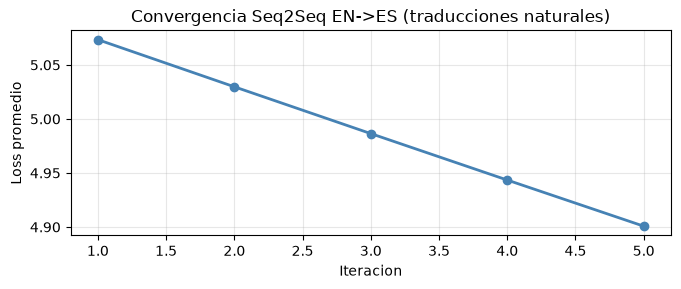

In [28]:
if losses_train:
    plt.figure(figsize=(7,3))
    plt.plot(range(1,6), losses_train, 'o-', color='steelblue', linewidth=2)
    plt.xlabel('Iteracion'); plt.ylabel('Loss promedio')
    plt.title('Convergencia Seq2Seq EN->ES (traducciones naturales)')
    plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig('convergencia_seq2seq.png', dpi=110, bbox_inches='tight')
    plt.show()

---
## Bloque 12: Preguntas de analisis

---

### Pregunta 1 (35 pts)

El corpus tiene tres tipos de pares: traducciones mas cortas en espanol (elision del sujeto: *she sings well* -> *canta bien*), mas largas (perifrasis: *the cat sleeps* -> *el gato esta durmiendo*), y del mismo largo.

a) Durante el entrenamiento con teacher forcing, el decoder para el par (*she sings well*, *canta bien*) corre 2 pasos y para (*the cat sleeps*, *el gato esta durmiendo*) corre 4 pasos. Explique como afecta esa diferencia al gradiente que llega a los pesos del encoder en cada caso. Use la formula del recorrido del gradiente $S + T$ pasos.

b) Durante la inferencia greedy, el decoder debe aprender a generar EOS en el momento correcto. Para un par donde el espanol es mas corto que el ingles, ¿que debe haber aprendido el modelo para detener la generacion antes de que el decoder produzca tantos tokens como el encoder proceso? ¿Que informacion del encoder codifica esa senal de parada?

c) Si ordenara el corpus de entrenamiento de menor a mayor largo de la secuencia de salida (curriculum learning), ¿esperaria que el modelo convergiera mas rapido, mas lento, o igual? Justifique en terminos del gradiente y del proceso de aprendizaje.

**Su respuesta a la Pregunta 1:**

a) Con la idea de la convención de que el gradiente se propaga a través de la red, cuando el decoder corre 2 pasos para el par (*she sings well*, *canta bien*), el gradiente que llega a los pesos del encoder es más corto en comparación con el par (*the cat sleeps*, *el gato esta durmiendo*), donde el decoder corre 4 pasos. Esto significa que para el primer caso, el gradiente tiene menos oportunidades de acumularse y ajustarse a los pesos del encoder, mientras que en el segundo caso, el gradiente tiene más pasos para propagarse y actualizar los pesos del encoder. En términos de la fórmula $S + T$, un mayor número de pasos en el decoder (S) permite una mayor influencia del gradiente en los pesos del encoder.
Además, en la oración más larga existen más pasos del decoder y entonces hay más perdidas que contribuyen al gradiente que recibe el contexto del encoder. Esto nos ayudaría a brindar más inforamación al encoder para que pueda aprender mejor la traducción pero el gradiente que llega a los primeros pasos del encoder será menos directo y más difuso, lo que podría dificultar el aprendizaje de las representaciones iniciales de la oración en inglés.

b) El modelo debe aprender que no se traduce por palabra es decir que no existe una relación uno a uno entre las palabras del inglés y del español. Después de generar las palabras necesarias, el decoder tendría que asgianr la probabilidad más alta a EOS para detener la generación. Por ejemplo she sings well -> canta bien, y al leer esas dos palabras el decoder debe aprender que ya tiene la información necesaria y terminar la traudcción. 
La señal de parada no está almacenada como un valor independiente dentro del encoder, sino que es más como una representación distribuida entre contextos context_h y context_c. Estos dos codifican el significado general de la entrada, estructura e información para traducirlo. Al mismo tiempo esta combinación entre contexto producido por el encoder y el estado actual del decoder les permite determinar que el contenido de la oración ya fue traducido.

c) Si se ordena de mas corto a más largo las salidas primerizas serían las más rápidas de aprender, debido a que las secuencias cortas requieren menos pasos y producen recorridos de gradiente más pequeños. Es por eso que el gradiente llega a los parámetros del encoder más directa y estable. El modelo aprendería lo más fácil o básico antes y generar primeras dos palabaras y definir bien el EOS. 
Después, los parámetros ya serían mejor ajustados para aprender secuencias más largas, ya que tiene las bases sería similar a aprender primero ejemplos fáciles y luego ejemplos más complejos. 
Habría que recalcar que esto no nos garantiza una pérdida final menor, ya que también existe la posibilidad de que el modelo tenga overfititng en los ejemplos más cortos y no generalice bien a los más largos. Es por ello que esperaría una convergencia más rápida al principio, pero no necesariamente una mejor generalización al final del entrenamiento.

---
### Pregunta 2 (35 pts)

a) En el Bloque 10 evalua el porcentaje de oraciones donde la primera palabra generada es correcta. Explique por que esa metrica es mas informativa que la loss de entrenamiento para evaluar la calidad de un sistema de traduccion, y cuales son sus limitaciones.

b) El Bloque 7 muestra que solo una fraccion de las columnas de `E_enc` tienen gradiente no cero en cada actualizacion. Con 78 pares de entrenamiento y 158 palabras en el vocabulario ingles, estime cuantas palabras del vocabulario podrian nunca recibir gradiente durante 5 iteraciones, y que implicacion tiene eso para la representacion de esas palabras.  

c) Si quisiera extender este modelo para traducir del espanol al ingles ademas de del ingles al espanol (un solo modelo bidireccional), describa dos enfoques arquitectonicos distintos y justifique cual de los dos preserva mejor la informacion aprendida en este laboratorio.

**Su respuesta a la Pregunta 2:**

a) La precisión de primera palabra es más informativa que la pérdida de entrenamiento porque mide condiciones completamente distintas. La pérdida se calcula bajo teacher forcing: en cada paso el decoder recibe la palabra correcta anterior sin importar qué haya predicho él mismo, entonces lo que en realidad mide es qué tan seguro estaba el modelo de la palabra correcta cuando nunca se le permitió desviarse de la respuesta real. Es una condición artificialmente favorable que nunca prueba si el modelo puede sostener una traducción por sí solo.

La métrica del Bloque 10, en cambio, se calcula con greedy_decode, el mismo procedimiento que se usaría en un caso real de uso: arranca únicamente desde SOS y el contexto que entregó el encoder, sin ninguna palabra correcta regalada en el camino. Por eso es más fiel a la calidad real del sistema, porque mide si el modelo efectivamente puede traducir por su cuenta y no si predice bien cuando se le da la respuesta anterior de forma gratuita.

Hay además una diferencia de naturaleza entre ambas métricas. La pérdida es un promedio continuo sobre todas las posiciones de todas las oraciones, un número abstracto de qué tan confiado estuvo el modelo en promedio. Dos modelos podrían tener exactamente la misma pérdida y comportarse de forma muy distinta en la práctica, por ejemplo uno podría acertar consistentemente las primeras palabras y desviarse después, mientras otro podría ser mediocre en toda la oración mendo. La precisión de primera palabra en cambio es un número concreto y a nivel de tarea: dice si el sistema sirvió o no sirvió para ese caso puntual.

Sus limitaciones son varias. Primero, solo evalúa una posición de la oración completa, un modelo podría clavar la primera palabra y arruinar completamente el resto sin que la métrica se entere. Segundo, es binaria, no da crédito parcial, si el modelo genera un sinónimo razonable o una palabra semánticamente cercana cuenta exactamente igual que si generara algo completamente disparatado. Tercero, con solamente 20 oraciones en el conjunto de prueba, el tamaño de muestra es pequeño, una sola oración que cambie de resultado mueve el porcentaje en 5 puntos, por lo que es una estimación bastante ruidosa. Y cuarto, no dice absolutamente nada sobre si el largo de la traducción generada fue razonable ni si el modelo aprendió a generar EOS en el momento correcto, que es justamente el fenómeno que observamos en el Bloque 10 al obtener traducciones vacías.

b)  En vez de estimar a ojo, calculamos directamente sobre el corpus cuántas palabras del vocabulario aparecen en las oraciones de entrenamiento. De las 158 palabras del vocabulario en inglés, solamente 123 aparecen al menos una vez en TRAIN_DATA. Eso deja 35 palabras (22% del vocabulario) que nunca reciben gradiente en ninguna de las 5 iteraciones, sin importar cuántas épocas se entrene.

Estas 35 se dividen en dos grupos con causas distintas:

- 31 son palabras de contenido real ("bike", "coffee", "bread", "phone", "letter", "car", entre otras) que existen en el vocabulario porque este se construyó sobre el corpus completo de 78 oraciones (build_vocab usa CORPUS_COMPLETO, no solo TRAIN_DATA), pero que por el azar del split 75/25 terminaron apareciendo únicamente en las 20 oraciones de TEST_DATA. Como el encoder nunca procesa esas oraciones durante el entrenamiento, get_embedding nunca selecciona esas columnas específicas de E_enc.
- 4 son los tokens especiales (PAD, UNK, SOS, EOS), que quedan huérfanos por diseño: las oraciones en inglés nunca contienen SOS ni EOS, y como el vocabulario se construyó con todas las palabras reales presentes en el corpus, UNK tampoco llega a dispararse nunca.

La implicación es que esas 35 columnas de E_enc permanecen exactamente en su valor de inicialización aleatoria (torch.randn(...) * 0.1) para siempre, sin ningún ajuste, porque el problema no es una cuestión de pocas repeticiones sino de que el mecanismo de selección de embeddings jamás las visita. Si en algún momento se le presentara al modelo una oración nueva que contenga alguna de esas 31 palabras, el encoder la procesaría usando un vector sin ningún significado aprendido, ruido puro con la misma forma que un embedding real, y el modelo tendría que compensar apoyándose únicamente en el contexto de las palabras vecinas que sí fueron entrenadas.

c) 
Un primer enfoque sería utilizar un solo encoder y un solo decoder y para lograr la traducción entre ambos idiomas, se utilizarían parámetros compartidos para ambos idiomas. Se podría construir un vocabulario conjunto inglés-español y agregar un token que indique el idioma de salida; por ejemplo, el token <2ES> para traducir al español y el token <2EN> para traducir al inglés.

En este enfoque, el modelo recibiría ejemplos de entrenamiento en las dos direcciones:

$$
\text{inglés} \rightarrow \text{español}
$$

$$
\text{español} \rightarrow \text{inglés}
$$

El token de dirección permitiría que el decoder identificara el idioma en el que debe generar la respuesta. Este enfoque comparte gran parte de los parámetros y podría facilitar la transferencia de información entre ambos idiomas.

Sin embargo, los mismos pesos tendrían que aprender dos funciones diferentes, lo que podría provocar interferencia entre las dos direcciones de traducción.

Un segundo enfoque sería mantener componentes separados para cada idioma:

Un encoder para inglés.
Un encoder para español.
Un decoder para inglés.
Un decoder para español.

Los dos encoders producirían vectores de contexto con la misma dimensión. De esta forma, cualquiera de los encoders podría conectarse con el decoder correspondiente al idioma de salida.

Para traducir del inglés al español se utilizaría:

$$
\text{Encoder}{EN} \rightarrow \text{Decoder}{ES}
$$

Para traducir del español al inglés se utilizaría:

$$
\text{Encoder}{ES} \rightarrow \text{Decoder}{EN}
$$

El segundo enfoque preservaría mejor lo aprendido durante este laboratorio, porque el encoder inglés y el decoder español actuales podrían conservar sus pesos.

Solamente sería necesario que lograramos incluir un encoder español y un decoder inglés. Esto nos ayudaría a reducir   el riesgo de que el entrenamiento de la dirección inversa modificara o destruyera la información ya aprendida para la traducción del inglés al español porque los pesos del encoder y decoder originales no se verían afectados por el entrenamiento de la dirección inversa.

La desventaja es que este enfoque requiere una mayor cantidad de parámetros, debido a que se mantienen encoders y decoders separados para cada idioma. Además , el entrenamiento de ambos idiomas podría requerir más tiempo y recursos computacionales, ya que se estarían entrenando más componentes del modelo. Sin embargo, este enfoque permite una mayor especialización de los encoders y decoders para cada idioma, lo que podría resultar en una mejor calidad de traducción en ambos sentidos.

---
### Pregunta 3 (30 pts)

a) Si convirtiera este seq2seq en un autoencoder para comprimir oraciones en espanol, describa exactamente los tres cambios de codigo necesarios en el Bloque 9. Sea especifico sobre la funcion de perdida, los tokens de entrada y salida del decoder, y los vocabularios.

b) En el seq2seq, el backward fluye desde la perdida hasta `E_enc` a traves de $S + T$ pasos. En un autoencoder sobre el mismo corpus, ¿ese recorrido seria el mismo, mas corto o mas largo? Justifique considerando que las oraciones de entrada y salida son iguales.

c) El vector de contexto $\mathbf{c}$ de dimension 32 debe comprimir toda la informacion de la entrada. Para las oraciones mas largas del corpus (*nosotros nos reunimos cada semana*, 5 palabras), ¿es suficiente esa dimension? ¿Que pasaria con la calidad de la reconstruccion si redujera la dimension a 2?

**Su respuesta a la Pregunta 3:**

a)  Los tres cambios necesarios en el Bloque 9 son los siguientes.

Primero, los vocabularios: dejaría de existir la distinción entre src_vocab (inglés) y tgt_vocab (español). Tanto el encoder como el decoder trabajarían con un único vocabulario español, entonces E_enc y E_dec tendrían el mismo tamaño de columnas (tgt_V en ambos casos, ya no src_V para uno y tgt_V para el otro), porque ya no hay dos idiomas involucrados, solo uno.

Segundo, los tokens de entrada del encoder: actualmente el encoder lee tokenize_src(src_sentence), la oración en inglés. En el autoencoder, el encoder tendría que leer la misma oración en español que el decoder va a reconstruir, tokenizada sin SOS/EOS (igual que tokenize_src no agrega tokens especiales). Es decir, ya no habría un par (inglés, español), habría una sola oración en español que se usa dos veces: una vez como entrada del encoder, y la misma otra vez como base del target del decoder.

Tercero, los tokens de entrada y salida del decoder no cambian de forma, dec_input_idx sigue siendo [SOS, w1, ..., wn] y dec_target_idx sigue siendo [w1, ..., wn, EOS], exactamente igual que ahora. Lo que cambia es de dónde salen esas palabras: ya no vienen de una traducción distinta, vienen de tokenizar la misma oración que entró al encoder.

Sobre la función de pérdida, la fórmula en sí no cambia, compute_loss sigue siendo entropía cruzada categórica sobre los logits del decoder contra el índice de la palabra correcta. Lo único que cambia es qué secuencia funge como esa "palabra correcta": antes era la traducción al español, ahora es la reconstrucción exacta de la oración que originalmente entró.

b) El recorrido no sería el mismo en todos los casos: depende de si la oración en inglés del par original era más larga o más corta que la oración en español, precisamente la asimetría que el corpus fue diseñado para tener.

En el autoencoder, como la entrada y la salida son la misma oración de N palabras, el encoder siempre corre T' = N pasos y el decoder siempre corre S' = N + 1 pasos (por el SOS extra al inicio). El recorrido total es siempre S' + T' = 2N + 1, sin excepción, determinado únicamente por el largo de esa oración.

En el seq2seq original, T (largo del inglés) y S (largo del español más uno) casi nunca coinciden, por diseño.

- "the cat sleeps" (T=3) → "el gato esta durmiendo" (4 palabras, S=5). Seq2seq: S+T = 5+3 = 8. Autoencoder sobre "el gato esta durmiendo" sola: 2(4)+1 = 9. El autoencoder es un paso más largo.
- "she sings well" (T=3) → "canta bien" (2 palabras, S=3). Seq2seq: S+T = 3+3 = 6. Autoencoder sobre "canta bien" sola: 2(2)+1 = 5. El autoencoder es un paso más corto.

Entonces  no es "más largo" ni "más corto" de forma general, es "depende de la oración", porque el seq2seq mezclaba dos largos independientes (inglés y español) mientras que el autoencoder colapsa eso en un solo largo que se cuenta dos veces. El autoencoder elimina la asimetría que hace interesante a este corpus en particular.

c)  Para una oración de 5 palabras, 32 dimensiones reales alcanzan de sobra, y es importante entender por qué no es una coincidencia. El corpus completo tiene apenas 78 oraciones distintas, el modelo no necesita generalizar a combinaciones nuevas de palabras, solo necesita distinguir y reconstruir un conjunto finito y pequeño de oraciones ya vistas. Para identificar cuál de 78 oraciones es, en principio alcanzarían unas pocas dimensiones (log2(78) ≈ 6.3 bits de información distinguible), y encima el decoder no depende únicamente del vector de contexto inicial: en cada paso también recibe la palabra que él mismo generó en el paso anterior, lo que le da información adicional para mantenerse en el camino correcto de esa oración específica. 32 dimensiones son un margen generoso para este corpus tan chico.

Si redujera la dimensión a 2, el problema no es que "2 números no alcancen matemáticamente" (dos números reales tienen infinita precisión en teoría), el problema es práctico: con precisión de punto flotante finita y un entrenamiento con gradiente basado en solo 5 épocas y un corpus pequeño, ese espacio de 2 dimensiones se vuelve un cuello de botella real donde muchas oraciones distintas terminan mapeadas a puntos muy cercanos entre sí, sin espacio suficiente para mantenerlas separadas. Esto afectaría primero y más severamente a las oraciones más largas y con más contenido específico, como la de 5 palabras, porque son las que más información distintiva necesitan empacar en ese mismo espacio reducido. Es la maleta con solo dos compartimentos: alcanza para llevar un par de objetos genéricos, pero no para empacar el detalle fino de una oración específica cuando además tiene que compartir esa misma maleta con otras 77 oraciones del corpus. Lo esperable sería que la reconstrucción de las oraciones largas se degrade notablemente, produciendo palabras genéricas o mezclando contenido de oraciones distintas que quedaron demasiado cerca en ese espacio de 2 dimensiones.

---
## Bloque 13: Nota automatica sobre la seccion de codigo

In [29]:
_PUNTOS = {
    'b2': ('Bloque 2:  Encoder forward',           18),
    'b4': ('Bloque 4:  Perdida CE categorica',       8),
    'b5': ('Bloque 5:  Backward decoder',           14),
    'b6': ('Bloque 6:  Backward encoder',           10),
    'b7': ('Bloque 7:  dE completa vs diccionario',  5),
    'b8': ('Bloque 8:  Actualizacion de pesos',      2),
    'b9': ('Bloque 9:  Convergencia 5 iteraciones',  3),
}
_TOTAL = 60
print('=' * 62)
print('  NOTA AUTOMATICA - SECCION DE CODIGO')
print('=' * 62)
_obtenido = 0
for key, (nombre, pts_max) in _PUNTOS.items():
    val = _resultados.get(key, False)
    pts = pts_max if val is True else 0
    _obtenido += pts
    print(f'  {"CORRECTO" if val is True else "PENDIENTE":10s} | {nombre:38s} | {pts:2d}/{pts_max} pts')
if isinstance(_resultados.get('b10'), float):
    print(f'  INFO       | B10 primera palabra test: {_resultados["b10"]:.1f}%')
print('-' * 62)
print(f'  Subtotal codigo:   {_obtenido}/{_TOTAL} puntos')
print('  Pendiente manual:')
print('    Bloque 12 preguntas : __/25 pts')
print('    Comentarios codigo  : __/15 pts')
print('-' * 62)
print('  TOTAL FINAL (sobre 100): __/100 pts')
print('=' * 62)

  NOTA AUTOMATICA - SECCION DE CODIGO
  CORRECTO   | Bloque 2:  Encoder forward             | 18/18 pts
  CORRECTO   | Bloque 4:  Perdida CE categorica       |  8/8 pts
  CORRECTO   | Bloque 5:  Backward decoder            | 14/14 pts
  CORRECTO   | Bloque 6:  Backward encoder            | 10/10 pts
  CORRECTO   | Bloque 7:  dE completa vs diccionario  |  5/5 pts
  CORRECTO   | Bloque 8:  Actualizacion de pesos      |  2/2 pts
  CORRECTO   | Bloque 9:  Convergencia 5 iteraciones  |  3/3 pts
  INFO       | B10 primera palabra test: 0.0%
--------------------------------------------------------------
  Subtotal codigo:   60/60 puntos
  Pendiente manual:
    Bloque 12 preguntas : __/25 pts
    Comentarios codigo  : __/15 pts
--------------------------------------------------------------
  TOTAL FINAL (sobre 100): __/100 pts
